# Big Data Lab Work

In [1]:
# # %pip install --force-reinstall "ipykernel==6.28.0"
# %pip uninstall -y ipykernel
# %pip install "ipykernel==6.28.0"

In [2]:
import ipykernel
print(ipykernel.__version__)
import polars as pl

6.28.0


In [3]:
!ls -lh /mnt/data/public/polymarket/

total 568K
-rwxrwxr-x+ 1 root root 9.5K Mar 27 16:52 README.md
-rwxrwxr-x+ 1 root root 523K Mar 27 16:52 banner.png
drwxrwxr-x+ 2 root root 4.0K Apr 26 11:42 features
drwxrwxr-x+ 2 root root 4.0K Apr 26 11:42 labels
drwxrwxr-x+ 2 root root 4.0K Apr 26 11:42 orderbook
drwxrwxr-x+ 2 root root 4.0K Apr 26 11:42 snapshots


In [4]:
!nvidia-smi

No devices were found


In [5]:
!ls -lh /mnt/data/public/polymarket/features

total 31M
-rwxrwxr-x+ 1 root root 31M Mar 27 16:52 ml_features_1m_v2.parquet


In [6]:
ls -lh /mnt/data/public/polymarket/labels

total 48M
-rwxrwxr-x+ 1 root root 15M Mar 27 16:52 market_targets.parquet*
-rwxrwxr-x+ 1 root root 33M Mar 27 16:52 trades.parquet*


In [7]:
ls -lh /mnt/data/public/polymarket/orderbook | head -5

total 35G
-rwxrwxr-x+ 1 root root 2.0G Mar 27 16:53 orderbook_2026-03-06.parquet*
-rwxrwxr-x+ 1 root root 2.1G Mar 27 16:55 orderbook_2026-03-07.parquet*
-rwxrwxr-x+ 1 root root 2.2G Mar 27 16:58 orderbook_2026-03-08.parquet*
-rwxrwxr-x+ 1 root root 1.3G Mar 27 17:00 orderbook_2026-03-09.parquet*


In [8]:
ls -lh /mnt/data/public/polymarket/snapshots | head -5

total 3.9G
-rwxrwxr-x+ 1 root root 302M Mar 27 17:32 snapshots_2026-03-06.parquet*
-rwxrwxr-x+ 1 root root 224M Mar 27 17:32 snapshots_2026-03-07.parquet*
-rwxrwxr-x+ 1 root root 228M Mar 27 17:32 snapshots_2026-03-08.parquet*
-rwxrwxr-x+ 1 root root  81M Mar 27 17:33 snapshots_2026-03-09.parquet*


In [9]:
!du -sch /mnt/data/public/polymarket/*

12K	/mnt/data/public/polymarket/README.md
524K	/mnt/data/public/polymarket/banner.png
31M	/mnt/data/public/polymarket/features
48M	/mnt/data/public/polymarket/labels
35G	/mnt/data/public/polymarket/orderbook
3.9G	/mnt/data/public/polymarket/snapshots
39G	total


## Reading Labels

In [36]:
# path = "/mnt/data/public/polymarket/snapshots/snapshots_2026-03-06.parquet"
path = "/mnt/data/public/polymarket/labels/market_targets.parquet"
path = "/mnt/data/public/polymarket/labels/trades.parquet"

# Polar Dataframe Version
df_market = pl.scan_parquet(path)
df_market.limit(100).collect().to_pandas()
# df_market.collect().describe()

,condition_id,side,outcome,price,size,timestamp,asset
0,0x0000dbb9f89318fa1324d4eed3dbc1ff192e764138c7...,BUY,No,0.790000,37.974682,1773535485,5475751391326417034909210895395778447254138036...
1,0x0000dbb9f89318fa1324d4eed3dbc1ff192e764138c7...,BUY,Yes,0.850000,5.000000,1773554079,8945166516904290673857818127174024824733820142...
2,0x0000dbb9f89318fa1324d4eed3dbc1ff192e764138c7...,BUY,Yes,0.850000,1.176466,1773569429,8945166516904290673857818127174024824733820142...
3,0x0000dbb9f89318fa1324d4eed3dbc1ff192e764138c7...,BUY,Yes,0.820000,1.219511,1773594139,8945166516904290673857818127174024824733820142...
4,0x0000dbb9f89318fa1324d4eed3dbc1ff192e764138c7...,BUY,No,0.540179,20.363634,1773636999,5475751391326417034909210895395778447254138036...
...,...,...,...,...,...,...,...
95,0x00028df20b436a1302c1bb0a3857cb314cd1d955bf49...,BUY,Yes,0.117000,9.400000,1773467031,6203533918419524766542070754953293312455087712...
96,0x00028df20b436a1302c1bb0a3857cb314cd1d955bf49...,BUY,Yes,0.120000,5.000000,1773467977,6203533918419524766542070754953293312455087712...
97,0x00028df20b436a1302c1bb0a3857cb314cd1d955bf49...,BUY,No,0.964000,5.000000,1773469173,8052752854383609253127056003138630746422603315...
98,0x00028df20b436a1302c1bb0a3857cb314cd1d955bf49...,BUY,No,0.963000,5.000000,1773469915,8052752854383609253127056003138630746422603315...


## Reading OrderBook

In [10]:
from pyspark.sql import SparkSession

spark = (
    SparkSession.builder
    .appName("View Polymarket Orderbook Parquet")
    .getOrCreate()
)

path = "/mnt/data/public/polymarket/orderbook/orderbook_2026-03-06.parquet"

df = spark.read.parquet(path)

# Show schema
df.printSchema()

# Show first 20 rows without truncating columns
df.show(20, truncate=False)

# Optional: see column names
print(df.columns)

# Optional: count rows, can be slow for 2GB+
print("Row count:", df.count())

root
 |-- timestamp_received: long (nullable = true)
 |-- timestamp_created_at: long (nullable = true)
 |-- market_id: string (nullable = true)
 |-- best_bid: float (nullable = true)
 |-- best_ask: float (nullable = true)
 |-- change_price: float (nullable = true)
 |-- change_size: float (nullable = true)
 |-- change_side: string (nullable = true)
 |-- token_id: string (nullable = true)
 |-- spread: float (nullable = true)
 |-- mid_price: float (nullable = true)

+------------------+--------------------+------------------------------------------------------------------+--------+--------+------------+-----------+-----------+-----------------------------------------------------------------------------+------------+---------+
|timestamp_received|timestamp_created_at|market_id                                                         |best_bid|best_ask|change_price|change_size|change_side|token_id                                                                     |spread      |mid_price|
+-

In [11]:
df.limit(10).toPandas()

,timestamp_received,timestamp_created_at,market_id,best_bid,best_ask,change_price,change_size,change_side,token_id,spread,mid_price
0,1772755441639,1772755441679,0x00000977017fa72fb6b1908ae694000d3b51f442c255...,0.009,0.013,0.009,1000.900024,BUY,4455468110807479331389362642427847115009165823...,0.004,0.011
1,1772755573852,1772755578267,0x00000977017fa72fb6b1908ae694000d3b51f442c255...,0.009,0.013,0.133,0.000000,SELL,4455468110807479331389362642427847115009165823...,0.004,0.011
2,1772755574100,1772755578472,0x00000977017fa72fb6b1908ae694000d3b51f442c255...,0.009,0.013,0.133,40.000000,SELL,4455468110807479331389362642427847115009165823...,0.004,0.011
3,1772755577386,1772755579670,0x00000977017fa72fb6b1908ae694000d3b51f442c255...,0.009,0.013,0.043,256.700012,SELL,4455468110807479331389362642427847115009165823...,0.004,0.011
4,1772755658205,1772755658227,0x00000977017fa72fb6b1908ae694000d3b51f442c255...,0.009,0.013,0.009,900.900024,BUY,4455468110807479331389362642427847115009165823...,0.004,0.011
5,1772755964391,1772755964470,0x00000977017fa72fb6b1908ae694000d3b51f442c255...,0.009,0.013,0.154,0.000000,SELL,4455468110807479331389362642427847115009165823...,0.004,0.011
6,1772756105891,1772756105922,0x00000977017fa72fb6b1908ae694000d3b51f442c255...,0.009,0.013,0.009,1000.900024,BUY,4455468110807479331389362642427847115009165823...,0.004,0.011
7,1772756146031,1772756146049,0x00000977017fa72fb6b1908ae694000d3b51f442c255...,0.009,0.013,0.699,200.000000,SELL,4455468110807479331389362642427847115009165823...,0.004,0.011
8,1772756200595,1772756200608,0x00000977017fa72fb6b1908ae694000d3b51f442c255...,0.009,0.013,0.043,250.000000,SELL,4455468110807479331389362642427847115009165823...,0.004,0.011
9,1772756240758,1772756240799,0x00000977017fa72fb6b1908ae694000d3b51f442c255...,0.009,0.013,0.699,0.000000,SELL,4455468110807479331389362642427847115009165823...,0.004,0.011


In [12]:
# df.groupBy("update_type") \
#   .count() \
#   .orderBy(col("count").desc()) \
#   .show(truncate=False)

## Reading Snapshots

In [13]:
path = "/mnt/data/public/polymarket/snapshots/snapshots_2026-03-06.parquet"

df2 = spark.read.parquet(path)
df2.limit(10).toPandas()

,timestamp_received,timestamp_created_at,market_id,update_type,data
0,1772755479569,1772755479636,0x0007deb167d0bb816e2e847a15435f3e384f97f9e3e2...,book_snapshot,"{""update_type"": ""book_snapshot"", ""market_id"": ..."
1,1772757306842,1772757306884,0x0007deb167d0bb816e2e847a15435f3e384f97f9e3e2...,book_snapshot,"{""update_type"": ""book_snapshot"", ""market_id"": ..."
2,1772758741660,1772758741701,0x0007deb167d0bb816e2e847a15435f3e384f97f9e3e2...,book_snapshot,"{""update_type"": ""book_snapshot"", ""market_id"": ..."
3,1772758749082,1772758749140,0x0007deb167d0bb816e2e847a15435f3e384f97f9e3e2...,book_snapshot,"{""update_type"": ""book_snapshot"", ""market_id"": ..."
4,1772757678461,1772757678492,0x0008043c3ed513ecff7ee64380fc943dc73eb3dfb667...,book_snapshot,"{""update_type"": ""book_snapshot"", ""market_id"": ..."
5,1772757825635,1772757825916,0x0008043c3ed513ecff7ee64380fc943dc73eb3dfb667...,book_snapshot,"{""update_type"": ""book_snapshot"", ""market_id"": ..."
6,1772758000770,1772758000792,0x0008043c3ed513ecff7ee64380fc943dc73eb3dfb667...,book_snapshot,"{""update_type"": ""book_snapshot"", ""market_id"": ..."
7,1772758045967,1772758045980,0x0008043c3ed513ecff7ee64380fc943dc73eb3dfb667...,book_snapshot,"{""update_type"": ""book_snapshot"", ""market_id"": ..."
8,1772758055224,1772758055235,0x0008043c3ed513ecff7ee64380fc943dc73eb3dfb667...,book_snapshot,"{""update_type"": ""book_snapshot"", ""market_id"": ..."
9,1772756288585,1772756288645,0x004230fb1f54a139d50ba2041e062a01461c931a6725...,book_snapshot,"{""update_type"": ""book_snapshot"", ""market_id"": ..."


# Big Data Mining

### Loading Data

In [14]:
# %pip install polars

To Speed Up Our Run we will be using Polars Dataframe for our Data Mining and Wrangling  
https://pola.rs/
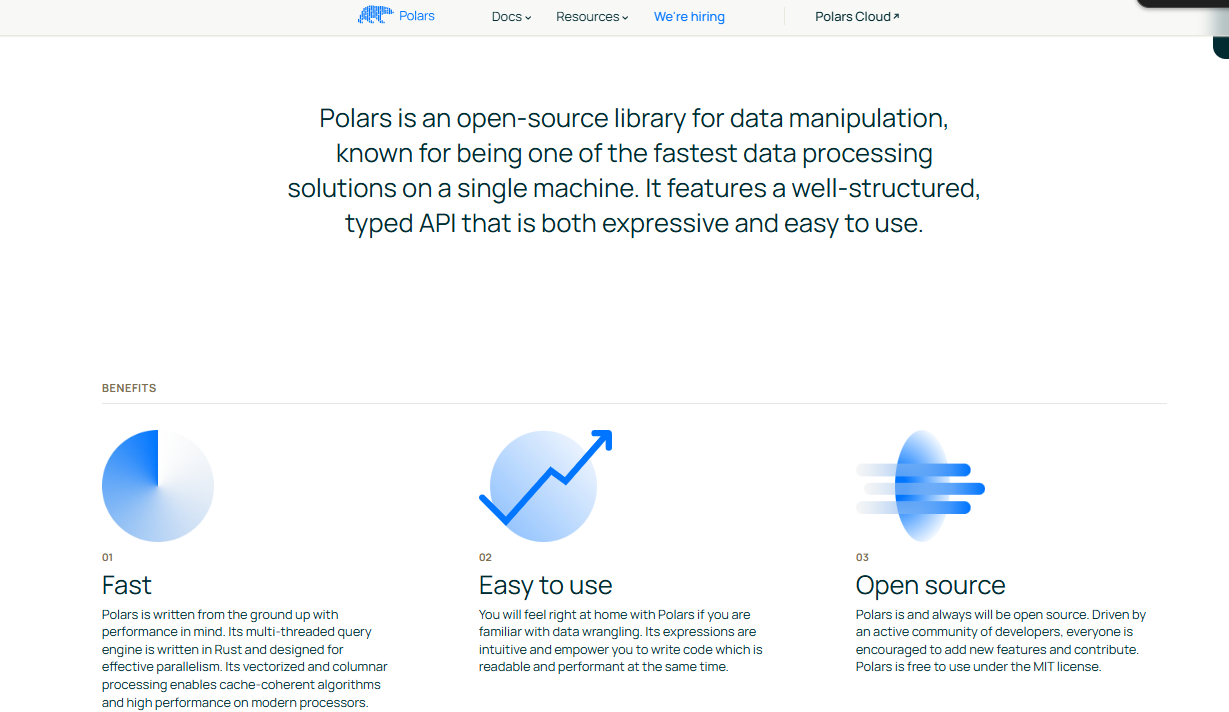

In [15]:
import polars as pl
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import MultipleLocator, AutoMinorLocator, MaxNLocator


Select what files to open and run

In [16]:
import os
import re
from datetime import datetime

# Reuse existing spark session
# spark = SparkSession.builder...getOrCreate()

DATA_DIR = "/mnt/data/public/polymarket"
ob_dir = f"{DATA_DIR}/orderbook"
snap_dir = f"{DATA_DIR}/snapshots"

# -----------------------------
# Date filter options
# -----------------------------
# Option A: inclusive range
START_DATE = "2026-03-06"   # set None to disable
END_DATE   = "2026-03-06"   # set None to disable

# Option B: explicit date set (takes priority if not None)
INCLUDE_DATES = None
# Example:
# INCLUDE_DATES = {"2026-03-01", "2026-03-03", "2026-03-06"}

date_pattern = re.compile(r"(\d{4}-\d{2}-\d{2})")

def extract_date(fname: str):
    m = date_pattern.search(fname)
    return m.group(1) if m else None

def keep_file_by_date(fname: str):
    d = extract_date(fname)
    if d is None:
        return False

    if INCLUDE_DATES is not None:
        return d in INCLUDE_DATES

    if START_DATE is None and END_DATE is None:
        return True

    dt = datetime.strptime(d, "%Y-%m-%d").date()
    if START_DATE is not None and dt < datetime.strptime(START_DATE, "%Y-%m-%d").date():
        return False
    if END_DATE is not None and dt > datetime.strptime(END_DATE, "%Y-%m-%d").date():
        return False
    return True

# Orderbook files filtered by date
ob_files_all = sorted([f for f in os.listdir(ob_dir) if f.endswith(".parquet")])
ob_files = [f for f in ob_files_all if keep_file_by_date(f)]
assert ob_files, "No orderbook parquet files matched your date filter."

print(f"Selected orderbook files: {len(ob_files)}")
for f in ob_files[:10]:
    print(" ", f)
if len(ob_files) > 10:
    print(" ...")

# Build full paths and read with Spark
ob_paths = [f"{ob_dir}/{f}" for f in ob_files]

Selected orderbook files: 1
  orderbook_2026-03-06.parquet


### Exploring Market Targets

Loading Data

In [28]:
# path = "/mnt/data/public/polymarket/snapshots/snapshots_2026-03-06.parquet"
path = "/mnt/data/public/polymarket/labels/market_targets.parquet"

# # Spark Dataframe Version
# df3 = spark.read.parquet(path)
# df3.limit(100).toPandas()

# # Polar Dataframe Version
# df3 = pl.scan_parquet(path)
# df3.limit(10).collect().to_pandas()

# # Spark Dataframe Version
# df3 = spark.read.parquet(path)
# df3.limit(100).toPandas()

# Polar Dataframe Version
df_market = pl.scan_parquet(path)
df_market.limit(10).collect().to_pandas()
df_market.collect().describe()

statistic,condition_id,question,category,end_date,closed,uma_status,volume,liquidity,clob_token_id_yes,clob_token_id_no,target
str,str,str,str,str,f64,str,f64,f64,str,str,f64
"""count""","""123895""","""123895""","""123895""","""123895""",123895.0,"""123895""",123895.0,123895.0,"""123895""","""123895""",23146.0
"""null_count""","""0""","""0""","""0""","""0""",0.0,"""0""",0.0,0.0,"""0""","""0""",100749.0
"""mean""",null,null,null,null,0.788143,null,41404.280168,3403.080497,null,null,0.257885
"""std""",null,null,null,null,null,null,997890.575147,54499.005838,null,null,0.43748
"""min""","""0x00000977017fa72fb6b1908ae694…",""" Eileen Gu citizenship revoked…","""""","""""",0.0,"""""",0.0,0.0,"""100000492764540534240318503884…","""100003518014986691537784890523…",0.0
"""25%""",null,null,null,null,null,null,0.0,0.0,null,null,0.0
"""50%""",null,null,null,null,null,null,0.0,0.0,null,null,0.0
"""75%""",null,null,null,null,null,null,0.0,0.0,null,null,1.0
"""max""","""0xffffee23a70d3172cafb93d9df5d…","""Ōita Trinita vs. Renofa Yamagu…","""""","""2029-01-20T00:00:00Z""",1.0,"""resolved""",1.7297e8,5.5462e6,"""999998020512762733701478486959…","""999993562505286457300544147609…",1.0


In [ ]:
# from pathlib import Path
# import shutil

# # source file (choose one)
# # src = Path("/mnt/data/public/polymarket/snapshots/snapshots_2026-03-06.parquet")
# src = Path("/mnt/data/public/polymarket/labels/market_targets.parquet")

# # destination in current working directory
# dst = Path.cwd() / src.name

# shutil.copy2(src, dst)
# print(f"Copied to: {dst.resolve()}")

Copied to: /home2/msds2026/laltonaga/market_targets.parquet


Filtering Condition_id/Market_id into Higher Liquidity and Volume Markets  
Removing Dead Markets

Rows before:  123,895
Rows after:   2,633
Rows removed: 121,262 (97.87%)


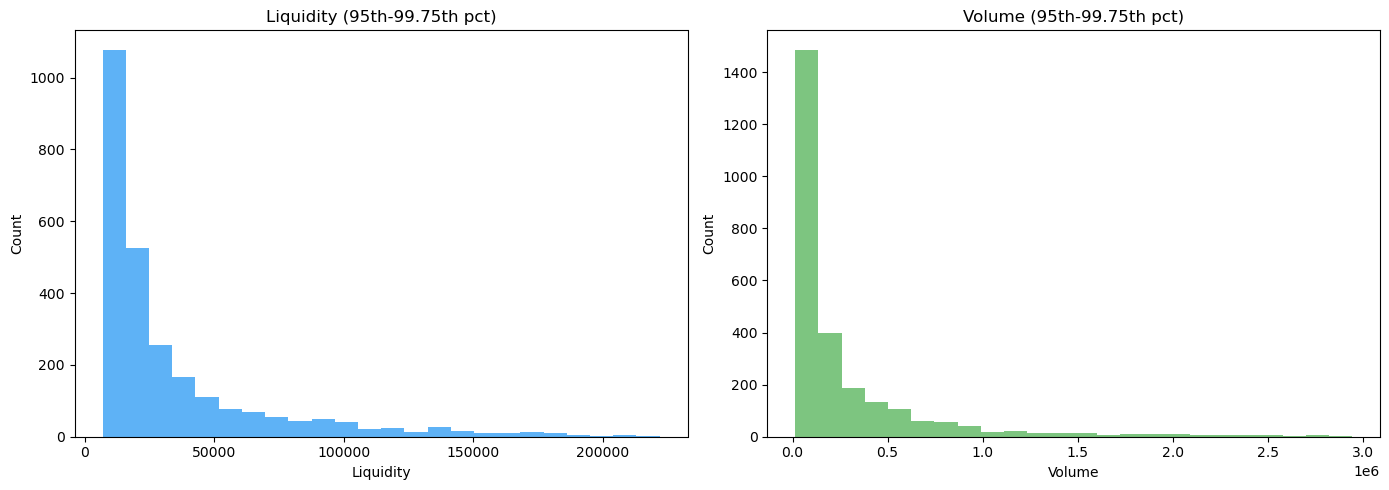

In [31]:
import numpy as np
import matplotlib.pyplot as plt

market_df = df_market.collect() if isinstance(df_market, pl.LazyFrame) else df_market

# keep middle 98% (1st to 99th percentile)
p_low, p_high = 95, 99.75
# p_low, p_high = 0, 100

liq_all = market_df["liquidity"].drop_nulls().to_numpy()
vol_all = market_df["volume"].drop_nulls().to_numpy()

liq_min, liq_max = np.percentile(liq_all, [p_low, p_high])
vol_min, vol_max = np.percentile(vol_all, [p_low, p_high])

before_rows = market_df.height

filtered = market_df.filter(
    pl.col("liquidity").is_between(liq_min, liq_max, closed="both") &
    pl.col("volume").is_between(vol_min, vol_max, closed="both")
)

after_rows = filtered.height
removed_rows = before_rows - after_rows
removed_pct = (removed_rows / before_rows * 100) if before_rows else 0.0

print(f"Rows before:  {before_rows:,}")
print(f"Rows after:   {after_rows:,}")
print(f"Rows removed: {removed_rows:,} ({removed_pct:.2f}%)")


liq = filtered["liquidity"].to_numpy()
vol = filtered["volume"].to_numpy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(liq, bins=24, color="#42A5F5", alpha=0.85, edgecolor="none")
axes[0].set_title(f"Liquidity ({p_low}th-{p_high}th pct)")
axes[0].set_xlabel("Liquidity")
axes[0].set_ylabel("Count")

axes[1].hist(vol, bins=24, color="#66BB6A", alpha=0.85, edgecolor="none")
axes[1].set_title(f"Volume ({p_low}th-{p_high}th pct)")
axes[1].set_xlabel("Volume")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()


**Filtering Observation**  
A Large Majority of the Market Have Little to No Liquidity and Volume. We can classify these as dead markets or markets with little activity and most likely give no meaningful information

Using 1 day only considering markets with 97.5% to 99.75% of the liquidity and Volume Value
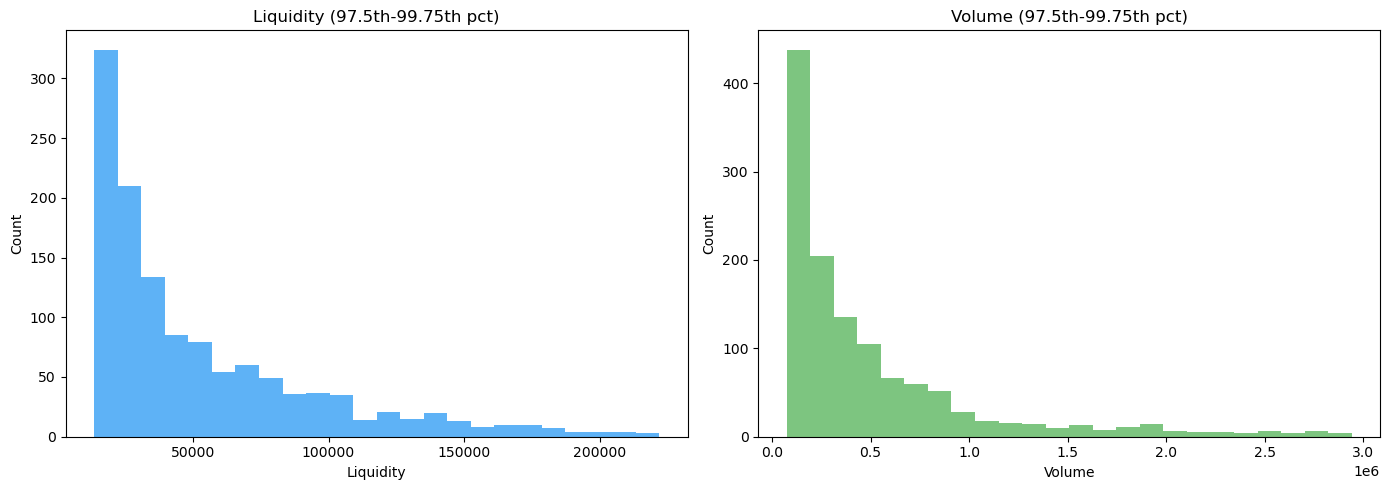

Using 1 day file all data
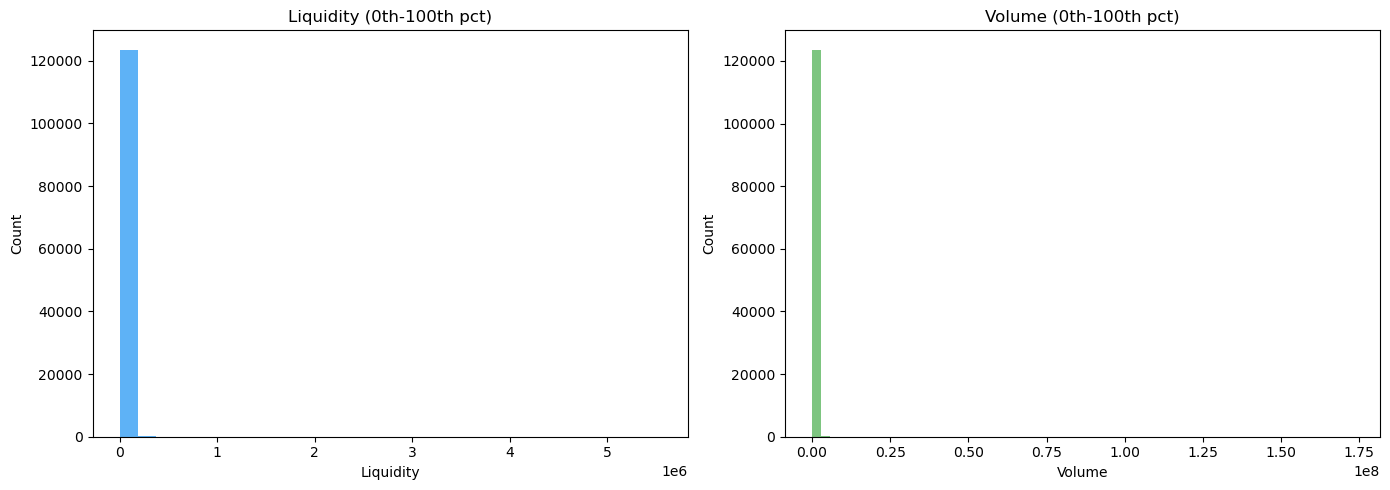

Topic Bucketing
- Here we attempt to categorize the markets using hugging face transformer with facebook model facebook/bart-large-mnli" for a zero-shot classification
- this helps to study the behavior of the markets by category and if underlying behaviors emerge from those observations

In [32]:
# Polar Dataframe Version
filtered.head(5).to_pandas()

,condition_id,question,category,end_date,closed,uma_status,volume,liquidity,clob_token_id_yes,clob_token_id_no,target
0,0xb48621f7eba07b0a3eeabc6afb09ae42490239903997...,BitBoy convicted?,,2026-03-31T12:00:00Z,False,,2.266330e+05,9631.43077,7546712961590831958303147464265888547913563043...,3842963720267267286970642336860752782302644680...,NaN
1,0x9c1a953fe92c8357f1b646ba25d983aa83e90c525992...,Russia-Ukraine Ceasefire before GTA VI?,,2026-07-31T12:00:00Z,False,,1.403228e+06,100309.56630,8501497159083948713316135768103773293754490207...,2527312495175492857904889758552137141356236738...,NaN
2,0x1fad72fae204143ff1c3035e99e7c0f65ea8d5cd9bd1...,New Rihanna Album before GTA VI?,,2026-07-31T12:00:00Z,False,,6.751036e+05,32729.52530,9802249026969240999812649612759703249033407008...,5383155306188300653073987728410593891972140877...,NaN
3,0x50ddb9cd80d5c271664a2ebb7fcaed1d0a148d82c8e8...,New Playboi Carti Album before GTA VI?,,2026-07-31T12:00:00Z,False,,7.094616e+05,29544.93060,8827504006008477337655718797221526751304984864...,9437620581602295554297963554227993296735991576...,NaN
4,0x84f8b70331323c2fba97d7ceaa9a35fb645a0770d0db...,Trump out as President before GTA VI?,,2026-07-31T12:00:00Z,False,,5.564197e+05,106972.10780,1089997232078979418764529355570116040679173891...,6453357980929752557903360996363493950101333285...,NaN


In [38]:
# !pip install transformers torch

In [43]:
!pwd

/home/msds2026/laltonaga


In [46]:
import polars as pl
import pandas as pd
from transformers import pipeline

# 1) Load question lookup
labels = pl.read_parquet("slt3a/Lab 1/Lab Notebook-Enzo.ipynb")
labels_lu = (
    labels
    .select(["condition_id", "question"])
    .unique(subset=["condition_id"])
)

# 2) Attach question text to your filtered table
filtered_with_q = (
    filtered
    .join(labels_lu, on="condition_id", how="left")
    .filter(pl.col("question").is_not_null())
)

# 3) Convert to pandas for easy iteration
pdf = filtered_with_q.select([
    "condition_id", "question", "volume", "liquidity", "target"
]).to_pandas()

# Optional: dedupe repeated questions per condition_id before classifying
# pdf_unique = pdf.drop_duplicates(subset=["condition_id"]).copy() # RUNS ENTIRE DATASET
pdf_unique = pdf.drop_duplicates(subset=["condition_id"]).head(5).copy() # TEST RUN on smaller dataset

# 4) Zero-shot classifier
classifier = pipeline(
    "zero-shot-classification",
    model="facebook/bart-large-mnli"
)

candidate_labels = ["politics", "sports", "crypto", "economy", "world events", "others"]

# 5) Classify (top label + score)
def classify_question(q):
    r = classifier(q, candidate_labels=candidate_labels, multi_label=False)
    return pd.Series({
        "pred_label": r["labels"][0],
        "pred_score": r["scores"][0]
    })

pdf_unique[["pred_label", "pred_score"]] = pdf_unique["question"].apply(classify_question)

# 6) If you want predictions back on all filtered rows
out = pdf.merge(
    pdf_unique[["condition_id", "pred_label", "pred_score"]],
    on="condition_id",
    how="left"
)

out.head(10)


ComputeError: parquet: File out of specification: The file must end with PAR1

### Exploring Filtered OrderBook Ticks

In [33]:
import polars as pl
import numpy as np

market_df = df_market.collect() if isinstance(df_market, pl.LazyFrame) else df_market

p_low, p_high = 97.5, 99.75
liq_all = market_df["liquidity"].drop_nulls().to_numpy()
vol_all = market_df["volume"].drop_nulls().to_numpy()
liq_min, liq_max = np.percentile(liq_all, [p_low, p_high])
vol_min, vol_max = np.percentile(vol_all, [p_low, p_high])

filtered = market_df.filter(
    pl.col("liquidity").is_between(liq_min, liq_max, closed="both") &
    pl.col("volume").is_between(vol_min, vol_max, closed="both")
)

# Keep mapping from condition_id -> question
market_map = (
    filtered
    .select(
        pl.col("condition_id").cast(pl.Utf8).alias("market_id"),
        pl.col("question")
    )
    .unique(subset=["market_id"])   # avoids duplicates per market_id
)

market_ids = market_map["market_id"].to_list()

sample_file = ob_files[-2] if len(ob_files) > 1 else ob_files[0]
ob_lf = pl.scan_parquet(f"{DATA_DIR}/orderbook/{sample_file}").with_columns(
    pl.col("market_id").cast(pl.Utf8)
)

chunk_size = 20_000
parts = []

for i in range(0, len(market_ids), chunk_size):
    ids_chunk = market_ids[i:i + chunk_size]
    map_chunk = market_map.filter(pl.col("market_id").is_in(ids_chunk))

    part = (
        ob_lf
        .join(map_chunk.lazy(), on="market_id", how="inner")  # includes question
        .with_row_index("row_idx")
        .filter(pl.col("row_idx") % 500 == 0)
        .drop("row_idx")
        .collect(engine="streaming")
    )
    if part.height > 0:
        parts.append(part)

sample = pl.concat(parts, how="vertical") if parts else pl.DataFrame()

print(f"Sample: {sample.height:,} rows, {sample.width} columns")
if sample.height:
    print(f"Unique markets in sample: {sample['market_id'].n_unique():,}")

sample.select(["market_id", "question","spread"]).head(5).to_pandas()


Sample: 29,257 rows, 12 columns
Unique markets in sample: 1,074


,market_id,question,spread
0,0x006e3bc30b325c9cd4e4a35e33738e7f49634dc353f8...,Will a province schedule a referendum to leave...,0.080
1,0x00ca3a4205ea548274f06891fd4b703160675842dd01...,Will the Chicago Bulls win the NBA Eastern Con...,0.001
2,0x01529e40f3b4cdf5eafe074adfe1bb9c152d57747ad9...,Will Elon Musk be richest person on December 31?,0.020
3,0x024b68f77bfc019341ee3db8f57c103334e4b9430bba...,"Will Bitcoin dip to $45,000 by December 31, 2026?",0.020
4,0x0214efd795ce4e8a54884faa52bacd4eeea7b4958fcf...,Will Justin Rose win the 2026 Masters tournament?,0.001


In [23]:
labels = pl.read_parquet("/mnt/data/public/polymarket/labels/market_targets.parquet")

labels_lu = (
    labels
    .select(["condition_id", "question"])
    .unique(subset=["condition_id"])
    .with_columns(pl.col("condition_id").cast(pl.Utf8))
)

median_spread_table = (
    sample
    .with_columns(pl.col("market_id").cast(pl.Utf8))
    .filter(pl.col("spread") > 0)
    .group_by("market_id")
    .agg([
        pl.col("spread").median().alias("median_spread"),
        pl.len().alias("ticks"),
    ])
    .join(labels_lu, left_on="market_id", right_on="condition_id", how="left")
    .select(["market_id", "question", "median_spread", "ticks"])
    .sort("median_spread", descending=False)   # True = widest first, False = tightest first
)

median_spread_table.head(30).to_pandas()

,market_id,question,median_spread,ticks
0,0xcc5494faf5ceca60a77a46db255b8c8e30b1bcc7d94d...,Based FDV above $500M one day after launch?,0.001,1
1,0xda9e24f8b6b8f71f02a79fe9d27348f6cbf2ff670cbe...,Will Charlie Kirk win the Nobel Peace Prize in...,0.001,19
2,0x79bc9eae1f5ce8f3f58648f45e7ff7cf182a8314e2d1...,Will Ukraine win Eurovision 2026?,0.001,40
3,0x201f51d2d892c41c5bfa6568a0a2f93ab2ea426e87dd...,"Will Ethereum reach $10,000 by December 31, 2026?",0.001,2
4,0xd4adc3e7d85d7bd90d11e6680fc775376ef568e88ee3...,Foreign intervention in Gaza by March 31?,0.001,26
5,0x8e29cb5c6b8d6b8d259114ffca2796fb378d1e0575f8...,Will the Denver Broncos win the 2027 NFL leagu...,0.001,17
6,0x1dd5f687b0f7aaa76ac2d2f2ea328ed825902e835a44...,Will the Carolina Panthers win the 2027 NFL le...,0.001,25
7,0xffc4681fe848a8bb55bcc97f774377199d05845164b1...,Will the New York Giants win the 2027 NFL leag...,0.001,11
8,0x508c917d0ee4a7a5535e825c3f85ee47d27fc1e72f88...,Will the New York Jets win the 2027 NFL league...,0.001,29
9,0xda6293438c50b71777cfa237c0e359e0586e9b5255c2...,Will Sergio Garcia win the 2026 Masters tourna...,0.001,26


### Exploring OrderBook Ticks  
Each Row is a single price change event on a Polymarket's YES token order book.

In [123]:

sample_file = ob_files[-2] if len(ob_files) > 1 else ob_files[0]
sample = (
    pl.scan_parquet(f"{DATA_DIR}/orderbook/{sample_file}")
    .with_row_index("row_idx")
    .filter(pl.col("row_idx") % 500 == 0)
    .drop("row_idx")
    .collect()
)

print(f"Sample: {sample.height:,} rows, {sample.width} columns")
print(f"Columns: {sample.columns}")
print(f"\nUnique markets in sample: {sample['market_id'].n_unique():,}")
print(f"Time range: {sample['timestamp_received'].min()} → {sample['timestamp_received'].max()}")
print()
# print(sample.head(5))
sample.head(5).to_pandas()

Sample: 651,949 rows, 11 columns
Columns: ['timestamp_received', 'timestamp_created_at', 'market_id', 'best_bid', 'best_ask', 'change_price', 'change_size', 'change_side', 'token_id', 'spread', 'mid_price']

Unique markets in sample: 21,621
Time range: 1772755200036 → 1772841599822



,timestamp_received,timestamp_created_at,market_id,best_bid,best_ask,change_price,change_size,change_side,token_id,spread,mid_price
0,1772755441639,1772755441679,0x00000977017fa72fb6b1908ae694000d3b51f442c255...,0.009,0.013,0.009,1000.900024,BUY,4455468110807479331389362642427847115009165823...,0.004,0.0110
1,1772756244014,1772756244062,0x0007deb167d0bb816e2e847a15435f3e384f97f9e3e2...,0.040,0.510,0.990,460.160004,SELL,4438688628612889517647685406937935453728225550...,0.470,0.2750
2,1772756261567,1772756261773,0x0008043c3ed513ecff7ee64380fc943dc73eb3dfb667...,0.002,0.018,0.609,30.000000,SELL,9768490592734555345549427858290912491204693022...,0.016,0.0100
3,1772758503818,1772758503842,0x0008043c3ed513ecff7ee64380fc943dc73eb3dfb667...,0.003,0.018,0.782,0.000000,SELL,9768490592734555345549427858290912491204693022...,0.015,0.0105
4,1772756425111,1772756425128,0x000bb906e8ad1b550e1eee94a73258e285450da2523e...,0.440,0.510,0.020,47.279999,BUY,8545931238741427168707217611371952486946208819...,0.070,0.4750


Statistics Check:  
For Reference the entire dataset should be  
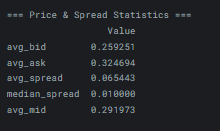

In [24]:
# Basic statistics on the core price columns
print("=== Price & Spread Statistics ===")
print(sample.select([
    pl.col("best_bid").mean().alias("avg_bid"),
    pl.col("best_ask").mean().alias("avg_ask"),
    pl.col("spread").mean().alias("avg_spread"),
    pl.col("spread").median().alias("median_spread"),
    pl.col("mid_price").mean().alias("avg_mid"),
]).to_pandas().T.rename(columns={0: "Value"}))

=== Price & Spread Statistics ===
                  Value
avg_bid        0.344361
avg_ask        0.403838
avg_spread     0.059478
median_spread  0.010000
avg_mid        0.374099


In [27]:
sample.describe()

statistic,timestamp_received,timestamp_created_at,market_id,best_bid,best_ask,change_price,change_size,change_side,token_id,spread,mid_price
str,f64,f64,str,f64,f64,f64,f64,str,str,f64,f64
"""count""",651949.0,651949.0,"""651949""",651949.0,651949.0,651949.0,651949.0,"""651949""","""651949""",651949.0,651949.0
"""null_count""",0.0,0.0,"""0""",0.0,0.0,0.0,0.0,"""0""","""0""",0.0,0.0
"""mean""",1.7728e12,1.7728e12,null,0.344361,0.403838,0.470794,7547.546387,null,null,0.059478,0.374099
"""std""",2.5316e7,2.5316e7,null,0.300549,0.30976,0.309343,170780.1875,null,null,0.153499,0.295381
"""min""",1.7728e12,1.7728e12,"""0x00000977017fa72fb6b1908ae694…",0.0,0.0009,0.001,0.0,"""BUY""","""100000490830271269851920749661…",9.0338e-8,0.00045
"""25%""",1.7728e12,1.7728e12,null,0.04,0.09,0.199,20.0,null,null,0.01,0.075
"""50%""",1.7728e12,1.7728e12,null,0.31,0.4,0.47,120.0,null,null,0.01,0.374502
"""75%""",1.7728e12,1.7728e12,null,0.56,0.639005,0.73,540.23999,null,null,0.03,0.575
"""max""",1.7728e12,1.7728e12,"""0xffff6c984d7adab19e799c46d1a4…",0.9991,1.0,0.999,2.6071028e7,"""SELL""","""999984093668140585093249789034…",1.0,0.99955


Spread Distribution

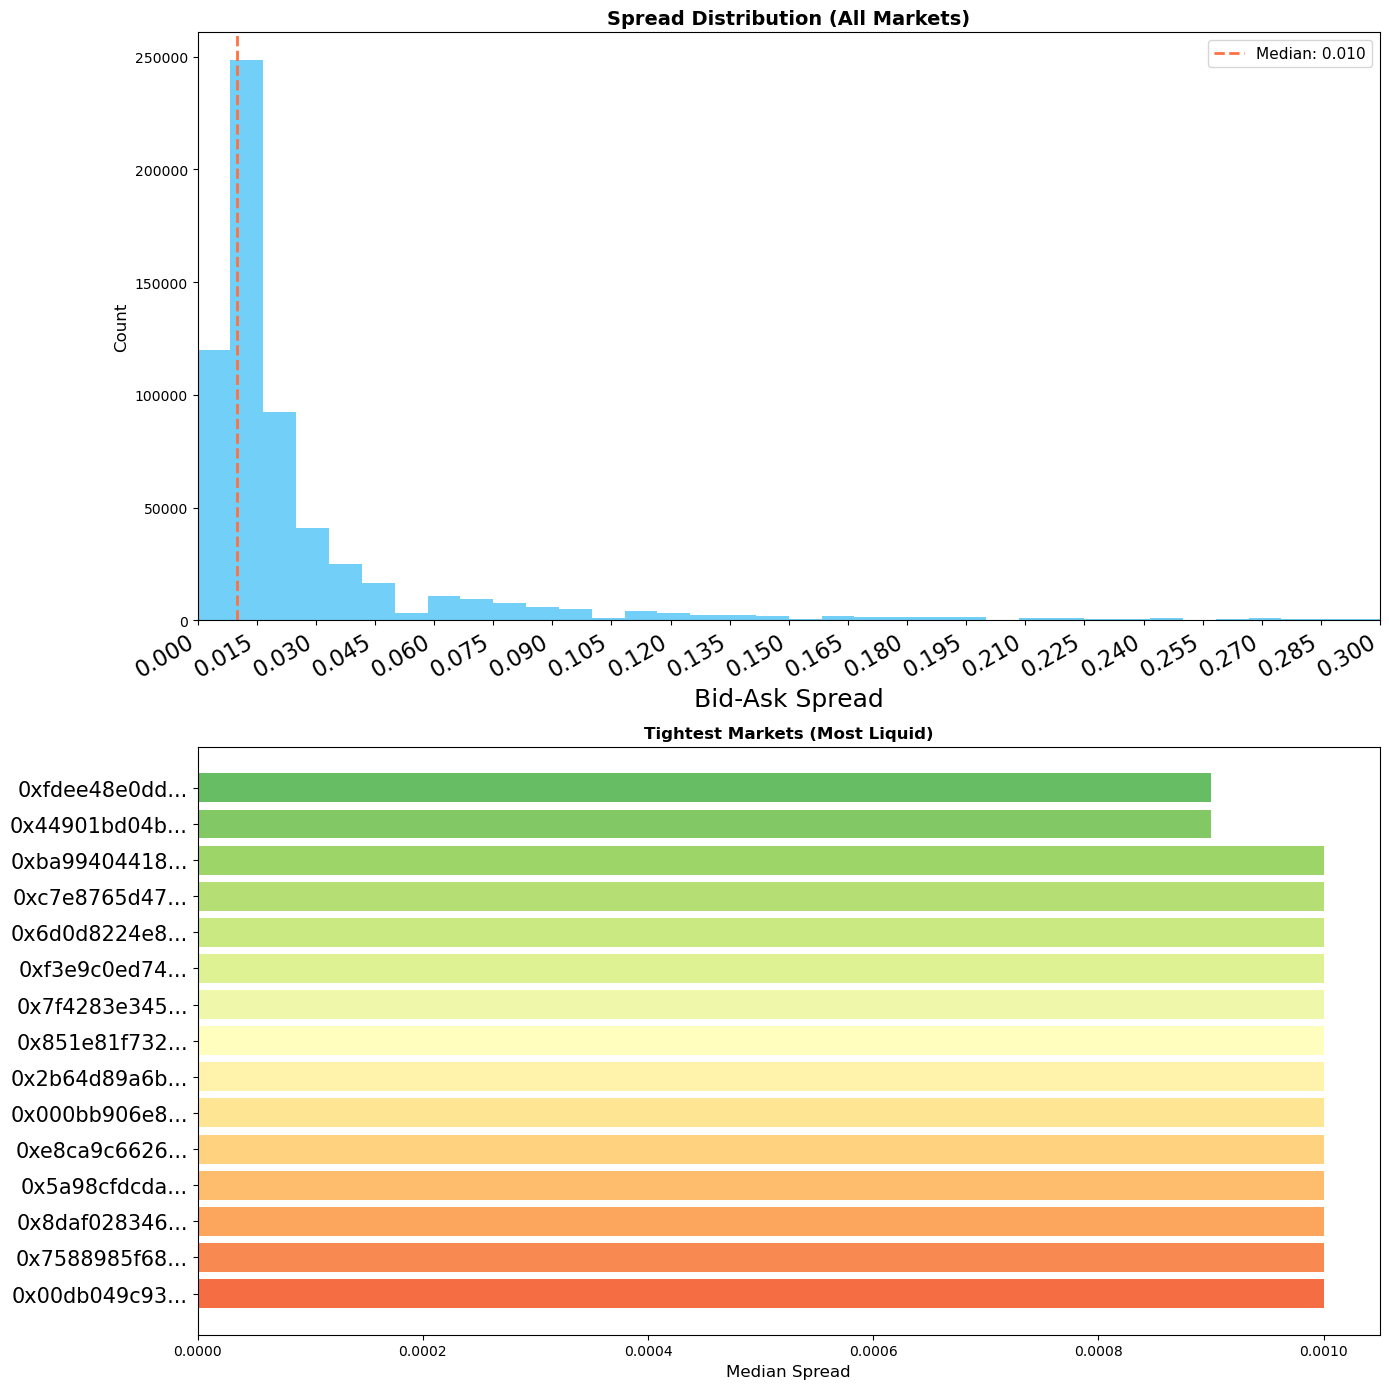

In [124]:
spreads = sample.filter(pl.col("spread") > 0)["spread"].to_numpy()

fig, axes = plt.subplots(2, 1, figsize=(14, 14))

# Histogram
axes[0].hist(spreads, bins=120, color="#4FC3F7", edgecolor="none", alpha=0.8)
axes[0].axvline(np.median(spreads), color="#FF7043", linestyle="--", linewidth=2, label=f"Median: {np.median(spreads):.3f}")
axes[0].set_xlabel("Bid-Ask Spread", fontsize=18)
axes[0].set_ylabel("Count", fontsize=12)
axes[0].set_title("Spread Distribution (All Markets)", fontsize=14, fontweight="bold")
axes[0].legend(fontsize=11)
axes[0].set_xlim(0, min(0.3, np.percentile(spreads, 99)))
axes[0].tick_params(axis="x", labelsize=16)
plt.setp(axes[0].get_xticklabels(), rotation=30, ha="right")
axes[0].xaxis.set_major_locator(MultipleLocator(0.015))   # change step as needed

# Top markets by tightest spreads
market_spreads = (
    sample.group_by("market_id")
    .agg([
        pl.col("spread").median().alias("median_spread"),
        pl.len().alias("ticks"),
    ])
    .sort("median_spread")
    .head(15)
)
ms = market_spreads.to_pandas()
colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(ms)))
axes[1].barh(range(len(ms)), ms["median_spread"], color=colors)
axes[1].set_yticks(range(len(ms)))
axes[1].set_yticklabels([mid[:12] + "..." for mid in ms["market_id"]], fontsize=15)
axes[1].set_xlabel("Median Spread", fontsize=12)
axes[1].set_title("Tightest Markets (Most Liquid)", fontsize=12, fontweight="bold")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

In [ ]:
labels = pl.read_parquet("/mnt/data/public/polymarket/labels/market_targets.parquet")

labels_lu = (
    labels
    .select(["condition_id", "question"])
    .unique(subset=["condition_id"])
)

tightest_table = (
    sample
    .filter(pl.col("spread") > 0)
    .group_by("market_id")
    .agg([
        pl.col("spread").median().alias("median_spread"),
        pl.len().alias("ticks"),
    ])
    .sort("median_spread")
    .head(30)
    .join(labels_lu, left_on="market_id", right_on="condition_id", how="left")
    .select(["market_id", "question", "median_spread", "ticks"])
)

tightest_table.to_pandas()


,market_id,question,median_spread,ticks
0,0x44901bd04b493e6a4cc7c6b7640acf0b53de8c1bc470...,None,0.0009,1
1,0xfdee48e0dd07452900fc3ce2ad1b1d68721b853fad7e...,None,0.0009,1
2,0xba3613600df5d77e6dd3056858f7734021fbe4bbc8e7...,None,0.0010,5
3,0x1bcfbf3799c5df7b055e8305f8b50c91de33802fd699...,Will Avatar: Fire and Ash win Best Visual Effe...,0.0010,50
4,0x4fb46c96d8573a51885cd6f6140057ee88421d5f8fe1...,None,0.0010,2
5,0x7893446a643d6034cfb0e0f1c65b84b355ada9417971...,None,0.0010,2
6,0x5eb61b9f349028ebc8fdbc43b4697acac76203068790...,None,0.0010,1
7,0x72a498c34e4d4b09974da799274fdbebc0a7c10607af...,None,0.0010,6
8,0x3c40ee5b31e88f45a3e5bfabacb8dc3450b546f110f5...,None,0.0010,3
9,0xdc264ddcb7d68727947b085f60be8c1186589d3b53e9...,None,0.0010,13
